# Full comment-recall analysis

**Metric 2 (substance side of H1).** For each config, what fraction of the
human-flagged issues does the review actually cover? Recall reads the per-config
final reviews against human ground-truth comments via the MARG §6 three-stage
alignment pipeline (extract → match → filter) on `gpt-5-mini`.

This is the cleaner substance signal that win-rate can't give: win-rate is partly a
leader writing-style preference, whereas recall is grounded in concrete issues the
human reviewers raised.

`n_comments` rides along as a **verbosity guard** — a review can inflate recall simply
by saying more, so recall is only meaningful read next to how many comments it emitted.

Sections: (1) recall ranking, (2) capability precondition, (3) verbosity guard,
(4) recall vs win-rate, (5) per-stratum robustness, (6) takeaways.

> Run `poetry run python eval/metrics/comment_recall.py --run-set full` first. Until
> `eval/results/full/comment_recall.json` exists this notebook prints a wait message
> and skips the figures (`READY` guard).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUN_SET = "full"

# Walk up until we find eval/ so the notebook runs regardless of CWD.
ROOT = Path.cwd()
while not (ROOT / "eval").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

RESULTS_DIR = ROOT / "eval" / "results" / RUN_SET
BATCHES = ROOT / "eval" / "batches.json"
DATASET = ROOT / "dataset" / "eval_sample_30.json"
FIG_DIR = ROOT / "eval" / "analysis" / "figures" / RUN_SET
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- palette (seaborn deep quad) ---
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
MODEL_COLORS = {"A": PALETTE[0], "B": PALETTE[1], "C": PALETTE[2]}
MODEL_NAMES = {"A": "qwen3-32b", "B": "mistral-small-3.2", "C": "llama-3.3-70b"}
ROLE_COLORS = dict(zip(
    ("leader", "clarity", "experiments", "impact"), PALETTE
))
ROLES = ("leader", "clarity", "experiments", "impact")
C_HET, C_REF = PALETTE[0], PALETTE[1]  # blue het, orange ref
C_ANNOT, C_MUTED, C_REF_LINE, C_EDGE, C_ERR = (
    "#333333", "#555555", "#666666", "#FFFFFF", "#333333",
)
# --- layout constants (fixed legend gap from figure bottom) ---
LEGEND_Y = 0.035          # figure coords — same on every plot
MARGIN_NO_LEGEND = 0.12
MARGIN_LEGEND = 0.22      # barh / scatter with legend, no rotated x
MARGIN_XROT30 = 0.28
MARGIN_XROT45 = 0.32
MARGIN_HEATMAP = 0.28
SAVE_PAD = 0.12


def legend_bottom(*, xrot=0, titled=False):
    if xrot >= 40:
        b = MARGIN_XROT45
    elif xrot >= 20:
        b = MARGIN_XROT30
    else:
        b = MARGIN_LEGEND
    if titled:
        b += 0.04
    return b


def legend_below(
    fig, ax=None, *, handles=None, labels=None, ncol=2, title=None, xrot=0,
):
    """Figure-level legend at fixed LEGEND_Y. Returns bottom margin for save_fig."""
    if handles is None:
        if ax is None:
            raise ValueError("legend_below needs ax or explicit handles")
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        handles, labels = ax.get_legend_handles_labels()
    kw = dict(
        loc="lower center", bbox_to_anchor=(0.5, LEGEND_Y), ncol=ncol,
        fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
    )
    if title:
        kw["title"] = title
    fig.legend(handles, labels, **kw)
    return legend_bottom(xrot=xrot, titled=title is not None)


def annotate_configs(ax, x, y, configs, *, fontsize=7, offsets_by_name=None):
    """Config slug near each scatter point."""
    defaults = [
        (7, 5), (7, -7), (-7, 5), (-7, -7),
        (10, 0), (-10, 0), (0, 9), (0, -9),
    ]
    for i, (xi, yi, name) in enumerate(zip(x, y, configs)):
        dx, dy = (offsets_by_name or {}).get(name, defaults[i % len(defaults)])
        ax.annotate(
            name, (xi, yi), textcoords="offset points", xytext=(dx, dy),
            fontsize=fontsize, color=C_ANNOT,
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
        )


def pad_axes_for_labels(ax, *, xfrac=0.06, yfrac=0.08):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ax.set_xlim(x0 - (x1 - x0) * xfrac, x1 + (x1 - x0) * xfrac)
    ax.set_ylim(y0 - (y1 - y0) * yfrac, y1 + (y1 - y0) * yfrac)


def save_fig(fig, path, *, bottom=MARGIN_NO_LEGEND, top=0.90, left=None, right=None):
    kw = dict(bottom=bottom, top=top)
    if left is not None:
        kw["left"] = left
    if right is not None:
        kw["right"] = right
    fig.subplots_adjust(**kw)
    fig.savefig(path, bbox_inches="tight", pad_inches=SAVE_PAD)


LEGEND_KW = dict(
    loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2,
    fontsize=8, framealpha=0.95, edgecolor="#CCCCCC", frameon=True,
)

FIG_RANK, FIG_COMPACT = (8.5, 4.5), (6, 3.6)
FIG_SCATTER, FIG_PANEL, FIG_WIDE = (7, 5), (9.5, 3.8), (12, 4.0)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 8,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.alpha": 0.25, "grid.color": "#E0E0E0", "grid.linestyle": "-",
    "lines.linewidth": 1.5, "patch.linewidth": 0.5,
})


def fig_title(desc: str, *, n_papers: int | None = None, extra: str = "") -> str:
    """Notebook title — keep light; LaTeX captions carry detail."""
    parts = []
    if RUN_SET == "pilot":
        parts.append("pilot")
    if n_papers is not None and (RUN_SET == "pilot" or n_papers != 25):
        parts.append(f"n={n_papers} papers")
    if extra:
        parts.append(extra)
    return f"{desc} ({', '.join(parts)})" if parts else desc


batch = json.loads(BATCHES.read_text())[RUN_SET]
pool = batch["pool"]
slug_to_letter = {v: k for k, v in pool.items()}


def letter(value: str) -> str:
    if value in pool:
        return value
    return slug_to_letter.get(value, value)


def tuple_letters(cfg: str) -> tuple[str, ...]:
    m = batch["configs"][cfg]
    return tuple(letter(m[r]) for r in ROLES)


def is_homogeneous(cfg: str) -> bool:
    return len(set(tuple_letters(cfg))) == 1



# Paper -> stratum, for the per-stratum robustness view (§5).
stratum_by_paper = {p["id"]: p.get("stratum") for p in json.loads(DATASET.read_text())["papers"]}

RESULTS = RESULTS_DIR / "comment_recall.json"
READY = RESULTS.exists()

if not READY:
    print(f"comment_recall.json not found at {RESULTS}")
    print("The full comment-recall job is probably still running — re-run this notebook once it lands.")
    cr = None
    df = pd.DataFrame()
    per_paper = {}
else:
    cr = json.loads(RESULTS.read_text())
    per_config = cr["per_config"]
    per_paper = cr["per_paper"]

    rows = []
    for c in per_config:
        t = tuple_letters(c)
        recalls = [r["recall"] for r in per_paper[c].values()]
        ncs = [r["n_comments"] for r in per_paper[c].values()]
        n = len(recalls)
        rows.append({
            "config": c,
            "tuple": ",".join(t),
            "leader": t[0], "clarity": t[1], "experiments": t[2], "impact": t[3],
            "homogeneous": len(set(t)) == 1,
            "recall": per_config[c]["recall"],
            "recall_sem": (np.std(recalls, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "n_comments": per_config[c]["n_comments"],
            "n_comments_sem": (np.std(ncs, ddof=1) / np.sqrt(n)) if n > 1 else 0.0,
            "n_papers": n,
        })

    df = pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)

    best_homo = df.loc[df["homogeneous"], "recall"].max()
    best_het = df.loc[~df["homogeneous"], "recall"].max()

    print(f"run-set        : {RUN_SET}")
    print(f"alignment model: {cr['alignment_model']}")
    print(f"prompt version : {cr['prompt_version']}  (match_passes={cr['match_passes']}, threshold={cr['match_threshold']})")
    print(f"configs        : {len(df)}  ({int(df['homogeneous'].sum())} homogeneous references)")
    print(f"papers/config  : {df['n_papers'].min()}–{df['n_papers'].max()}")
    print(f"best homogeneous recall: {best_homo:.3f}   best heterogeneous recall: {best_het:.3f}")
    display(df.round(4))

run-set        : full
alignment model: openai/gpt-5-mini
prompt version : marg_comment_recall_v1  (match_passes=5, threshold=2)
configs        : 7  (3 homogeneous references)
papers/config  : 25–25
best homogeneous recall: 0.376   best heterogeneous recall: 0.325


,config,tuple,leader,clarity,experiments,impact,homogeneous,recall,recall_sem,n_comments,n_comments_sem,n_papers
0,All-A,"A,A,A,A",A,A,A,A,True,0.3765,0.0136,13.44,0.6220,25
1,specialist,"A,B,A,C",A,B,A,C,False,0.3248,0.0184,11.76,0.4214,25
2,swap_leader,"A,B,B,B",A,B,B,B,False,0.3127,0.0181,11.28,0.5308,25
3,rot_2,"B,C,A,B",B,C,A,B,False,0.3112,0.0185,11.16,0.5822,25
4,swap_experiments,"B,B,A,B",B,B,A,B,False,0.2998,0.0159,13.00,0.8505,25
5,All-C,"C,C,C,C",C,C,C,C,True,0.2889,0.0181,9.76,0.5075,25
6,All-B,"B,B,B,B",B,B,B,B,True,0.2728,0.0223,11.08,0.7116,25


## 1. Recall ranking

Mean fraction of human-flagged issues covered, per config, with SEM over papers.
Orange = homogeneous references, blue = heterogeneous. Dashed line = best homogeneous
recall (`All-A` here). This is the substance analogue of the win-rate ranking — compare
the two orderings in §4.

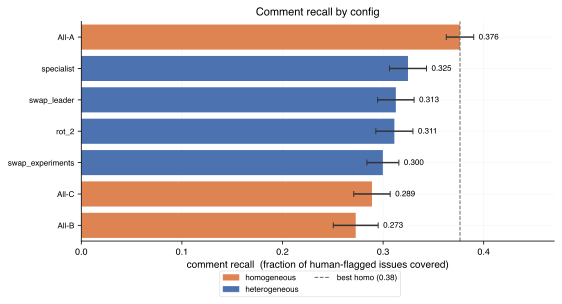

,config,tuple,recall,recall_sem,n_comments,n_papers
0,All-A,"A,A,A,A",0.3765,0.0136,13.44,25
1,specialist,"A,B,A,C",0.3248,0.0184,11.76,25
2,swap_leader,"A,B,B,B",0.3127,0.0181,11.28,25
3,rot_2,"B,C,A,B",0.3112,0.0185,11.16,25
4,swap_experiments,"B,B,A,B",0.2998,0.0159,13.00,25
5,All-C,"C,C,C,C",0.2889,0.0181,9.76,25
6,All-B,"B,B,B,B",0.2728,0.0223,11.08,25


In [2]:
assert READY, "comment_recall.json missing — run the metric first (see the setup cell message)."

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

d = df.sort_values("recall")
colors = [C_REF if h else C_HET for h in d["homogeneous"]]

bar_y = np.arange(len(d))
labels = d["config"].tolist()
fig, ax = plt.subplots(figsize=FIG_RANK)
ax.barh(bar_y, d["recall"], xerr=d["recall_sem"],
        color=colors, error_kw={"ecolor": C_ERR, "capsize": 3})
ax.axvline(best_homo, ls="--", color=C_REF_LINE, lw=1)
for yi, (v, hi) in enumerate(zip(d["recall"], d["recall_sem"])):
    ax.text(v + hi + 0.005, yi, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlabel("comment recall  (fraction of human-flagged issues covered)")
ax.set_title(fig_title("Comment recall by config"))
x_right = min(1.0, max((d["recall"] + d["recall_sem"]).max(), best_homo) + 0.08)
ax.set_xlim(right=x_right)
ax.set_yticks(bar_y)
ax.set_yticklabels(labels, fontsize=8)
ax.set_ylim(-0.5, len(d) - 0.5)

bottom = legend_below(fig, handles=[
    Patch(color=C_REF, label="homogeneous"),
    Patch(color=C_HET, label="heterogeneous"),
    Line2D([0], [0], ls="--", color=C_REF_LINE, lw=1,
           label=f"best homo ({best_homo:.2f})"),
], labels=["homogeneous", "heterogeneous", f"best homo ({best_homo:.2f})"], ncol=2)
save_fig(fig, FIG_DIR / "recall_by_config.png", bottom=bottom)
plt.show()

df[["config", "tuple", "recall", "recall_sem", "n_comments", "n_papers"]].round(4)


## 2. Capability precondition

Spread of the three homogeneous references (`All-A/B/C`). As with win-rate, if one model
runs away on recall, H2 (mechanism) has to be framed relative to that capability gap.

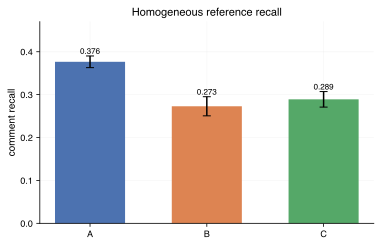

homogeneous recall spread (max - min): 0.104


In [3]:
homo = df[df["homogeneous"]].copy()
homo["model"] = homo["leader"]
homo = homo.sort_values("model")

fig, ax = plt.subplots(figsize=FIG_COMPACT)
ax.bar(homo["model"], homo["recall"], yerr=homo["recall_sem"],
       color=[MODEL_COLORS[m] for m in homo["model"]], capsize=4, width=0.6)
for x, (v, hi) in enumerate(zip(homo["recall"], homo["recall_sem"])):
    ax.text(x, v + hi + 0.005, f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(range(len(homo)))
ax.set_xticklabels(homo["model"], fontsize=9)
ax.set_ylabel("comment recall")
ax.set_title(fig_title("Homogeneous reference recall"))
ax.set_ylim(0, min(1.0, (homo["recall"] + homo["recall_sem"]).max() + 0.08))
save_fig(fig, FIG_DIR / "recall_capability.png", bottom=MARGIN_NO_LEGEND)
plt.show()

spread = homo["recall"].max() - homo["recall"].min()
print(f"homogeneous recall spread (max - min): {spread:.3f}")


## 3. Verbosity guard — recall vs. number of comments

Recall can be inflated by sheer volume (say more → cover more). Plot recall against
mean `n_comments` (Spearman ρ in title): if a config sits high on recall **and** far
right on comment count, read its recall with caution. A config that is high-recall at
modest verbosity is the genuinely efficient reviewer.

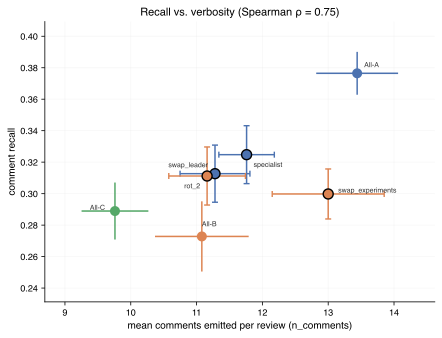

,config,tuple,n_comments,recall,recall_sem
0,All-A,"A,A,A,A",13.44,0.3765,0.0136
1,specialist,"A,B,A,C",11.76,0.3248,0.0184
2,swap_leader,"A,B,B,B",11.28,0.3127,0.0181
3,rot_2,"B,C,A,B",11.16,0.3112,0.0185
4,swap_experiments,"B,B,A,B",13.00,0.2998,0.0159
5,All-C,"C,C,C,C",9.76,0.2889,0.0181
6,All-B,"B,B,B,B",11.08,0.2728,0.0223


In [4]:
fig, ax = plt.subplots(figsize=FIG_SCATTER)
for _, r in df.iterrows():
    col = MODEL_COLORS[r["leader"]]
    ax.errorbar(r["n_comments"], r["recall"],
                xerr=r["n_comments_sem"], yerr=r["recall_sem"],
                fmt="o", ms=10, color=col,
                markeredgecolor="k", markeredgewidth=0 if r["homogeneous"] else 1.4,
                capsize=3, zorder=3)

if len(df) > 2:
    rk = df[["n_comments", "recall"]].rank()
    rho = rk["n_comments"].corr(rk["recall"])
    ax.set_title(fig_title("Recall vs. verbosity", extra=f"Spearman ρ = {rho:.2f}"))
else:
    ax.set_title(fig_title("Recall vs. verbosity"))
ax.set_xlabel("mean comments emitted per review (n_comments)")
ax.set_ylabel("comment recall")
pad_axes_for_labels(ax)
annotate_configs(ax, df["n_comments"], df["recall"], df["config"])
save_fig(fig, FIG_DIR / "recall_vs_verbosity.png", bottom=MARGIN_NO_LEGEND)
plt.show()

display(df[["config", "tuple", "n_comments", "recall", "recall_sem"]].round(4))


## 4. Recall vs. win-rate

Do the two quality signals agree? Win-rate is the judges' holistic preference (partly
leader writing style); recall is grounded coverage of human issues. Strong agreement
means win-rate isn't just a style artifact; divergence is itself interesting (e.g. a
config the judges like that misses real issues, or vice-versa).

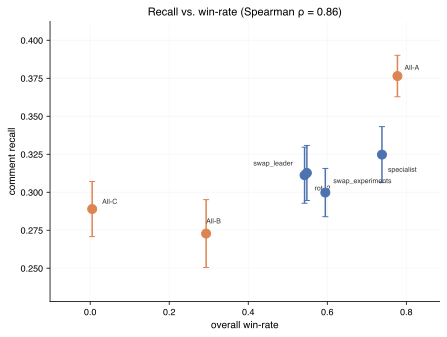

,config,tuple,recall,win_rate,n_comments
0,All-A,"A,A,A,A",0.3765,0.7775,13.44
1,specialist,"A,B,A,C",0.3248,0.7383,11.76
2,swap_leader,"A,B,B,B",0.3127,0.5483,11.28
3,rot_2,"B,C,A,B",0.3112,0.5425,11.16
4,swap_experiments,"B,B,A,B",0.2998,0.5950,13.00
5,All-C,"C,C,C,C",0.2889,0.0050,9.76
6,All-B,"B,B,B,B",0.2728,0.2933,11.08


In [5]:
wr_path = RESULTS_DIR / "win_rate.json"
if not READY:
    print("comment_recall.json not ready — skipping.")
elif not wr_path.exists():
    print("win_rate.json not found — showing recall ranking only.")
    display(df[["config", "tuple", "recall", "n_comments"]].round(4))
else:
    wr = json.loads(wr_path.read_text())
    m = df.copy()
    m["win_rate"] = m["config"].map(lambda c: wr["per_config"].get(c, {}).get("overall", np.nan))

    fig, ax = plt.subplots(figsize=FIG_SCATTER)
    for _, r in m.iterrows():
        col = C_REF if r["homogeneous"] else C_HET
        ax.errorbar(r["win_rate"], r["recall"], yerr=r["recall_sem"],
                    fmt="o", ms=9, color=col, capsize=3, zorder=3)

    valid = m.dropna(subset=["win_rate"])
    if len(valid) > 2:
        rk = valid[["win_rate", "recall"]].rank()
        rho = rk["win_rate"].corr(rk["recall"])
        ax.set_title(fig_title("Recall vs. win-rate", extra=f"Spearman ρ = {rho:.2f}"))
    else:
        ax.set_title(fig_title("Recall vs. win-rate"))
    ax.set_xlabel("overall win-rate")
    ax.set_ylabel("comment recall")
    pad_axes_for_labels(ax, xfrac=0.08, yfrac=0.10)
    annotate_configs(
        ax, m["win_rate"], m["recall"], m["config"],
        offsets_by_name={
            "swap_leader": (-14, 6),
            "rot_2": (10, -10),
            "swap_experiments": (8, 8),
            "specialist": (6, -12),
            "All-C": (10, 4),
        },
    )
    save_fig(fig, FIG_DIR / "recall_vs_winrate.png", bottom=MARGIN_NO_LEGEND)
    plt.show()
    display(m[["config", "tuple", "recall", "win_rate", "n_comments"]]
            .sort_values("recall", ascending=False).round(4))


## 5. Per-stratum robustness

Recall is macro-averaged over papers, so check it isn't driven by one stratum.
`controversial` papers (high rating disagreement) may have noisier human comment sets
than `normal` ones. Split each config's mean recall by paper stratum.

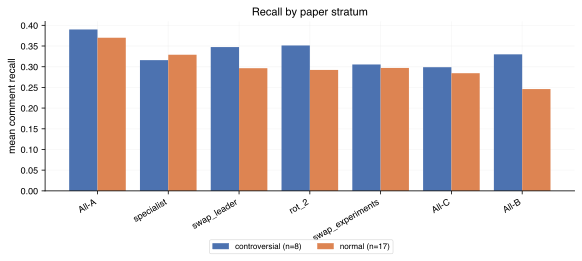

papers per stratum: {'controversial': 8, 'normal': 17}


stratum,controversial,normal
config,,
All-A,0.3900,0.3701
specialist,0.3159,0.3289
swap_leader,0.3474,0.2963
rot_2,0.3514,0.2923
swap_experiments,0.3055,0.2971
All-C,0.2989,0.2843
All-B,0.3299,0.2459


In [6]:
assert READY, "comment_recall.json missing — run the metric first."

from matplotlib.patches import Patch

STRATA = ("controversial", "normal")
STRATUM_COLORS = dict(zip(STRATA, PALETTE[:2]))

long = []
for cfg, papers in per_paper.items():
    for pid, row in papers.items():
        long.append({"config": cfg, "paper": pid,
                     "stratum": stratum_by_paper.get(pid, "unknown"),
                     "recall": row["recall"]})
long = pd.DataFrame(long)

pivot = (long.groupby(["config", "stratum"])["recall"].mean()
             .unstack("stratum")
             .reindex(columns=STRATA)
             .reindex(df["config"]))

x = np.arange(len(pivot))
w = 0.8 / len(STRATA)
fig, ax = plt.subplots(figsize=FIG_PANEL)
for i, stratum in enumerate(STRATA):
    ax.bar(x + i * w, pivot[stratum].values, width=w, label=stratum,
           color=STRATUM_COLORS[stratum])
ax.set_xticks(x + w * (len(STRATA) - 1) / 2)
ax.set_xticklabels(pivot.index, rotation=30, ha="right")
ax.set_ylabel("mean comment recall")
ax.set_title(fig_title("Recall by paper stratum"))

n_by_stratum = long.drop_duplicates("paper").groupby("stratum").size()
stratum_handles = [
    Patch(color=STRATUM_COLORS[s], label=f"{s} (n={n_by_stratum[s]})")
    for s in STRATA
]
bottom = legend_below(
    fig,
    handles=stratum_handles,
    labels=[h.get_label() for h in stratum_handles],
    ncol=2,
    xrot=30,
)
save_fig(fig, FIG_DIR / "recall_by_stratum.png", bottom=bottom)
plt.show()

print("papers per stratum:", n_by_stratum.to_dict())
pivot.round(4)


## 6. Takeaways

1. **Capability precondition (§2)** — `All-A` (0.376) still dominates on recall; spread across
   `All-A/B/C` is 0.104 (`All-B` 0.273, `All-C` 0.289). Same qwen baseline leads as on
   win-rate — H2 must be read relative to this gap.
2. **H1 / substance (§1)** — **fails on recall too**: best heterogeneous `specialist` (0.325)
   stays below `All-A` (0.376). No het config covers more human-flagged issues than the
   strongest homogeneous reference.
3. **Verbosity guard (§3)** — Spearman ρ ≈ 0.75 between recall and `n_comments`. `All-A` is
   high on both (0.376 recall, 13.4 comments) — part of its lead may be volume. `specialist`
   is the best het recall at modest verbosity (0.325 at 11.8 comments).
4. **Agreement with win-rate (§4)** — Spearman ρ ≈ 0.86: the two signals mostly agree. Main
   outlier is `All-C` (win-rate 0.005 vs recall 0.289): judges reject it, but it still flags
   ~29% of human issues. `swap_leader` shows the reverse pattern (win-rate 0.55, recall 0.31).
5. **Robustness (§5)** — `All-A` leads in **both** strata (normal 0.37, controversial 0.39).
   Unlike win-rate, `specialist` does not take the controversial stratum (0.32 vs `rot_2`
   0.35). Ranking is directionally stable but not identical across strata.